# 🏡 Global Airbnb Seasonal Tourism Analytics

### Author
Tejashwini R K

### Objective
Analyze how seasonal tourism patterns influence Airbnb pricing, occupancy, demand, and revenue across major cities using Python, SQL, and Power BI.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📥 Load Dataset

In [5]:
import os

# Path to New York dataset
data_path = "../datasets/New York"

# Check if files exist
print(os.listdir(data_path))

['New York calendar.csv', 'New York listings.csv', 'New York reviews.csv']


In [6]:
# Load New York datasets

listings = pd.read_csv("../datasets/New York/New York listings.csv")
calendar = pd.read_csv("../datasets/New York/New York calendar.csv")
reviews = pd.read_csv("../datasets/New York/New York reviews.csv")

print("✅ Datasets loaded successfully!")

✅ Datasets loaded successfully!


In [7]:
print("Listings Shape :", listings.shape)
print("Calendar Shape :", calendar.shape)
print("Reviews Shape  :", reviews.shape)

Listings Shape : (30259, 90)
Calendar Shape : (11152576, 5)
Reviews Shape  : (990170, 6)


In [8]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,NaN,1,0,1,0,1.24
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,NaN,NaN,2,0,2,0,2.12


In [9]:
calendar.head()

,listing_id,date,available,minimum_nights,maximum_nights
0,115535,2026-06-14,f,30,365
1,115535,2026-06-15,t,30,365
2,115535,2026-06-16,f,30,365
3,115535,2026-06-17,f,30,365
4,115535,2026-06-18,f,30,365


In [10]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2539,55688172,2015-12-04,25160947,Peter,Great host
1,2539,97474898,2016-08-27,91513326,Liz,Nice room for the price. Great neighborhood. J...
2,2539,105340344,2016-10-01,90022459,Евгений,Very nice apt. New remodeled.
3,2539,133131670,2017-02-20,116165195,George,Great place to stay for a while. John is a gre...
4,2539,138349776,2017-03-19,118432644,Carlos,.


## 🔍 Data Understanding

The first step in any data analysis project is to understand the structure, size, and quality of the dataset before performing any cleaning or analysis.

In [11]:
print("========== LISTINGS ==========")
listings.info()

print("\n========== CALENDAR ==========")
calendar.info()

print("\n========== REVIEWS ==========")
reviews.info()

========== LISTINGS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  object 
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  object 
 4   source                                        30259 non-null  object 
 5   name                                          30258 non-null  object 
 6   description                                   29357 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   30259 non-null  object 
 9   host_id                       

In [12]:
print("========== LISTINGS ==========")
display(listings.describe())

print("========== CALENDAR ==========")
display(calendar.describe())

print("========== REVIEWS ==========")
display(reviews.describe())

========== LISTINGS ==========


,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.025900e+04,3.025900e+04,0.0,3.025900e+04,2.991000e+04,0.0,29910.000000,29910.000000,29910.000000,29910.000000,...,21692.000000,21697.000000,21691.000000,21691.000000,0.0,30259.000000,30259.000000,30259.000000,30259.000000,21700.000000
mean,6.172513e+17,2.026061e+13,NaN,2.672815e+15,1.469574e+18,NaN,8.284754,5.653928,6.684286,5.631829,...,4.838066,4.821284,4.743640,4.633094,NaN,55.887141,45.630721,9.146601,0.095905,0.846505
std,6.155147e+17,8.855615e+00,NaN,6.705743e+16,2.417060e+16,NaN,3.934796,3.482520,3.889389,3.356700,...,0.373301,0.418090,0.388374,0.496439,NaN,174.246090,172.331916,36.412035,1.125182,1.847935
min,2.539000e+03,2.026061e+13,NaN,1.678000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.038760e+07,2.026061e+13,NaN,2.069159e+07,1.462882e+18,NaN,5.000000,3.000000,3.000000,3.000000,...,4.827500,4.820000,4.660000,4.530000,NaN,1.000000,0.000000,0.000000,0.000000,0.090000
50%,6.608782e+17,2.026061e+13,NaN,1.074344e+08,1.465524e+18,NaN,9.000000,6.000000,7.000000,5.000000,...,4.950000,4.960000,4.850000,4.760000,NaN,2.000000,1.000000,0.000000,0.000000,0.270000
75%,1.160901e+18,2.026061e+13,NaN,3.948700e+08,1.469572e+18,NaN,11.000000,9.000000,10.000000,8.000000,...,5.000000,5.000000,5.000000,4.920000,NaN,12.000000,3.000000,2.000000,0.000000,0.962500
max,1.707075e+18,2.026061e+13,NaN,1.704453e+18,1.706707e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,955.000000,955.000000,231.000000,22.000000,115.630000


========== CALENDAR ==========


,listing_id,minimum_nights,maximum_nights
count,1.115258e+07,1.115258e+07,1.115258e+07
mean,6.252407e+17,2.752926e+01,1.003804e+06
std,6.181998e+17,3.430474e+01,4.640444e+07
min,2.539000e+03,1.000000e+00,1.000000e+00
25%,3.043555e+07,3.000000e+01,1.800000e+02
50%,6.700833e+17,3.000000e+01,3.650000e+02
75%,1.164527e+18,3.000000e+01,1.125000e+03
max,1.707075e+18,1.124000e+03,2.147484e+09


========== REVIEWS ==========


,listing_id,id,reviewer_id
count,9.901700e+05,9.901700e+05,9.901700e+05
mean,2.722384e+17,6.896390e+17,8.222543e+14
std,4.451970e+17,5.925304e+17,3.714448e+16
min,2.539000e+03,3.149000e+03,1.400000e+01
25%,1.226760e+07,5.032227e+08,3.546830e+07
50%,3.418180e+07,7.296432e+17,1.219115e+08
75%,6.522797e+17,1.221038e+18,2.979384e+08
max,1.700185e+18,1.713974e+18,1.705312e+18


In [15]:
print("========== LISTINGS ==========")
display(listings.isnull().sum())

print("========== CALENDAR ==========")
display(calendar.isnull().sum())

print("========== REVIEWS ==========")
display(reviews.isnull().sum())

========== LISTINGS ==========


id                                                 0
listing_url                                        0
scrape_id                                          0
last_scraped                                       0
source                                             0
                                                ... 
calculated_host_listings_count                     0
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
reviews_per_month                               8559
Length: 90, dtype: int64

========== CALENDAR ==========


listing_id        0
date              0
available         0
minimum_nights    0
maximum_nights    0
dtype: int64

========== REVIEWS ==========


listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      3
comments         272
dtype: int64

In [14]:
print("Listings Duplicates :", listings.duplicated().sum())
print("Calendar Duplicates :", calendar.duplicated().sum())
print("Reviews Duplicates  :", reviews.duplicated().sum())

Listings Duplicates : 0
Calendar Duplicates : 0
Reviews Duplicates  : 0


## 🧹 Data Cleaning

To preserve the original dataset, a separate working DataFrame is created using only the columns required for analysis. This improves efficiency and keeps the cleaning process organized.

In [16]:
important_columns = [
    'id',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'property_type',
    'room_type',
    'accommodates',
    'bedrooms',
    'beds',
    'price',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
    'host_is_superhost'
]

airbnb = listings[important_columns].copy()

print("✅ Working dataset created!")
print("Shape:", airbnb.shape)

✅ Working dataset created!
Shape: (30259, 20)


In [17]:
airbnb.head()

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,price,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost
0,2539,Kensington,40.645937,-73.972164,Private room in condo,Private room,2,1.0,2.0,$113.97,4,34,64,339,10,4.80,0.08,60,6838.0,f
1,6848,Williamsburg,40.709350,-73.953420,Entire rental unit,Entire home/apt,3,2.0,1.0,$117.27,1,1,15,191,198,4.60,0.95,180,21109.0,t
2,6872,East Harlem,40.801070,-73.942550,Private room in condo,Private room,1,NaN,1.0,$80.06,0,0,11,286,2,5.00,0.04,60,4804.0,f
3,6990,East Harlem,40.787780,-73.947590,Private room in rental unit,Private room,1,NaN,1.0,$77.17,0,28,28,218,251,4.88,1.24,120,9260.0,t
4,7097,Fort Greene,40.691940,-73.973890,Private room in guest suite,Private room,2,NaN,2.0,$202.47,0,0,0,106,423,4.89,2.12,255,51630.0,t


In [18]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         30259 non-null  int64  
 1   neighbourhood_cleansed     30259 non-null  object 
 2   latitude                   30259 non-null  float64
 3   longitude                  30259 non-null  float64
 4   property_type              30259 non-null  object 
 5   room_type                  30259 non-null  object 
 6   accommodates               30259 non-null  int64  
 7   bedrooms                   19286 non-null  float64
 8   beds                       20839 non-null  float64
 9   price                      21515 non-null  object 
 10  availability_30            30259 non-null  int64  
 11  availability_60            30259 non-null  int64  
 12  availability_90            30259 non-null  int64  
 13  availability_365           30259 non-null  int

In [19]:
airbnb.dtypes

id                             int64
neighbourhood_cleansed        object
latitude                     float64
longitude                    float64
property_type                 object
room_type                     object
accommodates                   int64
bedrooms                     float64
beds                         float64
price                         object
availability_30                int64
availability_60                int64
availability_90                int64
availability_365               int64
number_of_reviews              int64
review_scores_rating         float64
reviews_per_month            float64
estimated_occupancy_l365d      int64
estimated_revenue_l365d      float64
host_is_superhost             object
dtype: object

In [20]:
airbnb['price'].head(10)

0    $113.97
1    $117.27
2     $80.06
3     $77.17
4    $202.47
5    $365.97
6    $154.87
7     $91.07
8        NaN
9        NaN
Name: price, dtype: object

In [21]:
# Remove '$' sign
airbnb['price'] = airbnb['price'].str.replace('$', '', regex=False)

# Convert to numeric
airbnb['price'] = pd.to_numeric(airbnb['price'], errors='coerce')

In [22]:
airbnb['price'].dtype

dtype('float64')

In [23]:
missing_df = pd.DataFrame({
    "Missing Values": airbnb.isnull().sum(),
    "Percentage": (airbnb.isnull().sum() / len(airbnb) * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
bedrooms,10973,36.26
beds,9420,31.13
price,9368,30.96
estimated_revenue_l365d,8744,28.90
review_scores_rating,8559,28.29
reviews_per_month,8559,28.29
host_is_superhost,349,1.15


In [24]:
airbnb[airbnb['price'].isna()].head(10)

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,price,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost
8,263888,Upper West Side,40.795418,-73.975632,Entire condo,Entire home/apt,2,1.0,NaN,NaN,9,15,33,56,251,4.99,1.43,255,NaN,f
9,265145,Theater District,40.762530,-73.983650,Entire rental unit,Entire home/apt,2,NaN,NaN,NaN,0,0,0,0,8,4.88,0.05,0,NaN,f
10,265506,Upper East Side,40.762800,-73.965100,Entire rental unit,Entire home/apt,6,2.0,NaN,NaN,0,0,0,0,11,4.89,0.06,0,NaN,f
13,267435,Rego Park,40.733330,-73.859330,Private room in rental unit,Private room,1,NaN,NaN,NaN,0,0,0,0,25,4.96,0.19,0,NaN,f
25,12192,East Village,40.722960,-73.983830,Private room in rental unit,Private room,1,NaN,NaN,NaN,0,0,0,0,316,4.40,1.56,120,NaN,t
27,268481,Williamsburg,40.715400,-73.940280,Entire condo,Entire home/apt,4,2.0,NaN,NaN,0,0,0,0,1,5.00,0.01,0,NaN,f
30,270139,Bushwick,40.704130,-73.927260,Private room in rental unit,Private room,1,NaN,NaN,NaN,0,0,0,0,39,4.69,0.25,0,NaN,f
36,139624,Crown Heights,40.674780,-73.951650,Entire rental unit,Entire home/apt,2,1.0,NaN,NaN,0,0,26,26,86,4.38,0.48,0,NaN,f
39,142069,East Village,40.725060,-73.979060,Entire rental unit,Entire home/apt,2,NaN,NaN,NaN,0,0,0,0,22,4.60,0.12,0,NaN,f
41,144148,East Village,40.722970,-73.985100,Private room in rental unit,Private room,2,NaN,NaN,NaN,0,0,0,0,32,4.53,0.22,0,NaN,f


In [25]:
airbnb['bedrooms'].value_counts(dropna=False)

bedrooms
1.0     11779
NaN     10973
2.0      5073
3.0      1712
4.0       461
5.0       150
6.0        57
0.0        15
7.0        13
9.0         9
8.0         8
10.0        3
12.0        2
14.0        1
15.0        1
19.0        1
11.0        1
Name: count, dtype: int64

In [26]:
airbnb['beds'].value_counts(dropna=False)

beds
1.0     12487
NaN      9420
2.0      4915
3.0      1837
4.0       929
5.0       314
6.0       167
8.0        72
7.0        70
9.0        14
10.0       10
12.0        6
13.0        5
11.0        5
17.0        2
40.0        1
20.0        1
16.0        1
18.0        1
21.0        1
25.0        1
Name: count, dtype: int64

### Key Observations

- Around 31% of listings have missing price values.
- Review-related columns have missing values because not every listing has received reviews.
- Bedroom and bed information is missing for a significant number of listings and requires further investigation before cleaning.
- The `host_is_superhost` column has very few missing values (1.15%) and can be handled easily during data cleaning.

### Missing Value Strategy

- Missing values were investigated before applying any cleaning.
- Bedroom and bed information was retained because missing values may represent incomplete host information or specific property types (e.g., studio apartments).
- Review-related missing values were retained because listings without reviews naturally have no rating or review frequency.
- Price values were not imputed. Rows with missing prices will only be excluded from analyses that specifically require price.
- The original information is preserved to avoid introducing inaccurate assumptions.

In [27]:
airbnb['host_is_superhost'].value_counts(dropna=False)

host_is_superhost
f      22814
t       7096
NaN      349
Name: count, dtype: int64

### Cleaning Decision: `host_is_superhost`

The `host_is_superhost` column contains only 1.15% missing values. Instead of removing these records or assuming they are not superhosts, missing values are replaced with **"Unknown"** to preserve the dataset while clearly identifying unavailable information.

In [28]:
# Replace missing values with 'Unknown'
airbnb['host_is_superhost'] = airbnb['host_is_superhost'].fillna('Unknown')

In [29]:
airbnb['host_is_superhost'].value_counts()

host_is_superhost
f          22814
t           7096
Unknown      349
Name: count, dtype: int64

In [30]:
airbnb['host_is_superhost'] = airbnb['host_is_superhost'].replace({
    't': 'Yes',
    'f': 'No'
})

airbnb['host_is_superhost'].value_counts()

host_is_superhost
No         22814
Yes         7096
Unknown      349
Name: count, dtype: int64

## 📊 EDA 1: Distribution of Airbnb Prices

### Business Question
What is the distribution of Airbnb listing prices in New York?

### Objective
Understand whether most Airbnb listings are budget-friendly, mid-range, or luxury properties.

In [31]:
# Create a dataset with only valid prices
price_data = airbnb.dropna(subset=['price'])

print("Number of listings with price:", len(price_data))

Number of listings with price: 20891


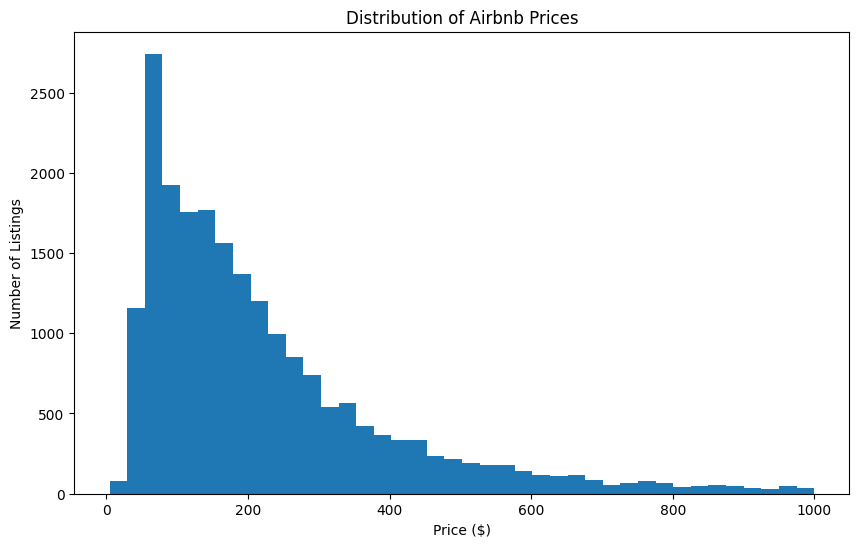

In [32]:
plt.figure(figsize=(10,6))

plt.hist(price_data['price'], bins=40)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

### Business Insight

- The majority of Airbnb listings are priced between approximately **$50 and $250**, indicating that the market is primarily composed of budget and mid-range accommodations.
- The price distribution is **positively (right) skewed**, meaning there are many moderately priced listings and relatively few high-priced luxury properties.
- A small number of listings exceed **$800**, representing premium accommodations within the New York Airbnb market.
- This suggests that while luxury listings exist, they make up only a small proportion of the overall market.

## 📊 EDA 2: Distribution of Room Types

### Business Question
Which room type is most commonly listed on Airbnb in New York?

### Objective
Analyze the distribution of Airbnb room types to understand the composition of the New York Airbnb market.

In [33]:
airbnb['room_type'].value_counts()

room_type
Entire home/apt    16808
Private room       12713
Hotel room           520
Shared room          218
Name: count, dtype: int64

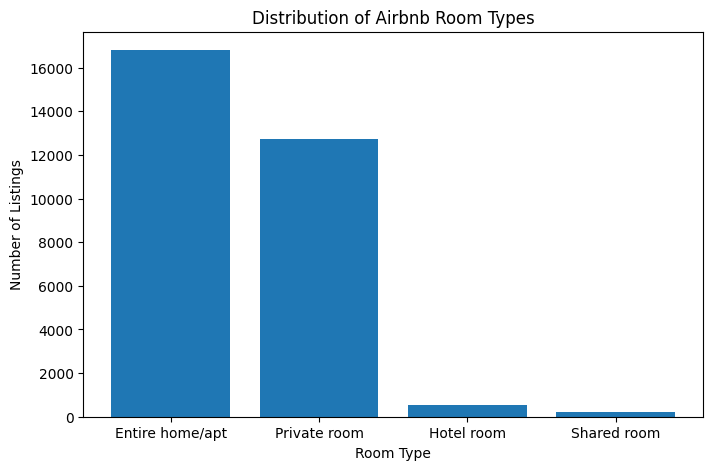

In [34]:
room_counts = airbnb['room_type'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(room_counts.index, room_counts.values)

plt.title("Distribution of Airbnb Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.show()

### Business Insight

- Entire home/apartment listings dominate the New York Airbnb market, accounting for the largest share of available accommodations.
- Private rooms also represent a significant portion of listings, indicating strong demand for more affordable accommodation options.
- Hotel rooms and shared rooms constitute only a small fraction of the marketplace.
- Overall, the New York Airbnb market is primarily composed of residential properties rather than traditional hotel accommodations.

## 📊 EDA 3: Average Price by Room Type

### Business Question
Which Airbnb room type has the highest average listing price in New York?

### Objective
Compare the average prices of different room types to identify premium accommodation categories.

In [35]:
# Calculate average price for each room type
avg_price = (
    airbnb
    .dropna(subset=['price'])
    .groupby('room_type')['price']
    .mean()
    .sort_values(ascending=False)
)

avg_price

room_type
Hotel room         445.293325
Entire home/apt    269.797485
Private room       157.245223
Shared room        125.403351
Name: price, dtype: float64

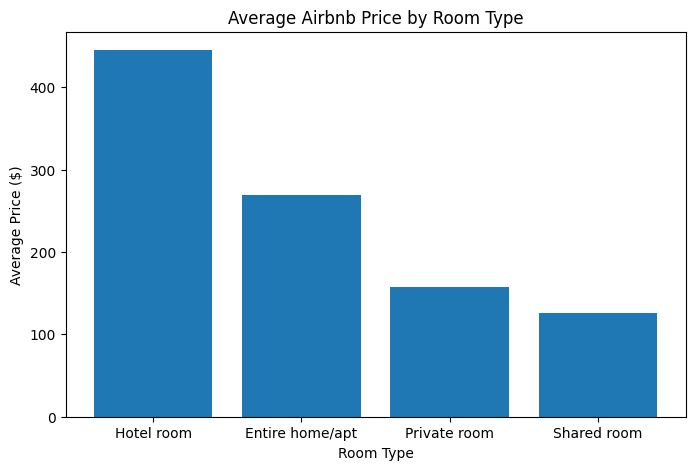

In [36]:
plt.figure(figsize=(8,5))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")

plt.show()

### Business Insight

- Hotel rooms have the highest average listing price, despite representing a small proportion of the market.
- Entire home/apartment listings are the second most expensive while also being the most common accommodation type.
- Private rooms offer a more affordable option for travelers compared to entire homes.
- Shared rooms have the lowest average price, making them the most budget-friendly accommodation category.

## 📊 EDA 4: Top 10 Neighborhoods by Number of Listings

### Business Question
Which neighborhoods have the highest number of Airbnb listings in New York?

### Objective
Identify the most popular neighborhoods for Airbnb hosting based on the number of active listings.

In [37]:
top_neighborhoods = airbnb['neighbourhood_cleansed'].value_counts().head(10)

top_neighborhoods

neighbourhood_cleansed
Bedford-Stuyvesant    2089
Midtown               1784
Williamsburg          1516
Harlem                1417
Hell's Kitchen        1365
Upper West Side       1194
Upper East Side       1187
Bushwick              1016
Crown Heights          876
Chelsea                733
Name: count, dtype: int64

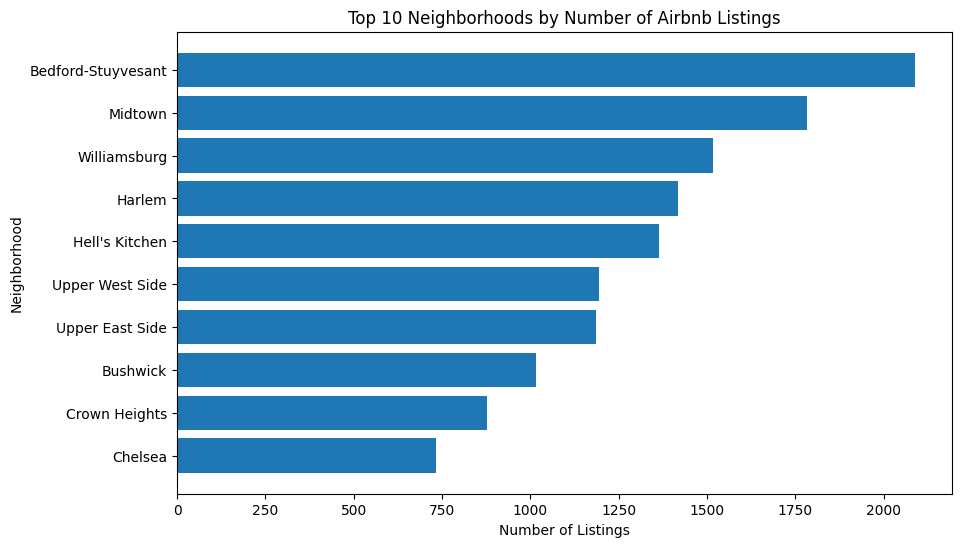

In [38]:
plt.figure(figsize=(10,6))

plt.barh(top_neighborhoods.index,
         top_neighborhoods.values)

plt.title("Top 10 Neighborhoods by Number of Airbnb Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")

plt.gca().invert_yaxis()

plt.show()

### Business Insight

- Bedford-Stuyvesant has the highest number of Airbnb listings among all neighborhoods in the dataset.
- Midtown ranks second, followed by Williamsburg and Harlem.
- Airbnb listings are concentrated in a limited number of neighborhoods rather than being evenly distributed across the city.
- Several neighborhoods from Brooklyn and Manhattan appear in the top 10, indicating that these boroughs have a strong Airbnb presence.

## 📊 EDA 5: Average Review Rating by Host Type

### Business Question
Do Superhosts receive higher review ratings than regular hosts?

### Objective
Compare the average review ratings of Superhosts and non-Superhosts to understand whether Superhost status is associated with higher customer satisfaction.

In [39]:
superhost_rating = (
    airbnb
    .dropna(subset=['review_scores_rating'])
    .groupby('host_is_superhost')['review_scores_rating']
    .mean()
)

superhost_rating

host_is_superhost
No         4.686727
Unknown    4.535703
Yes        4.858304
Name: review_scores_rating, dtype: float64

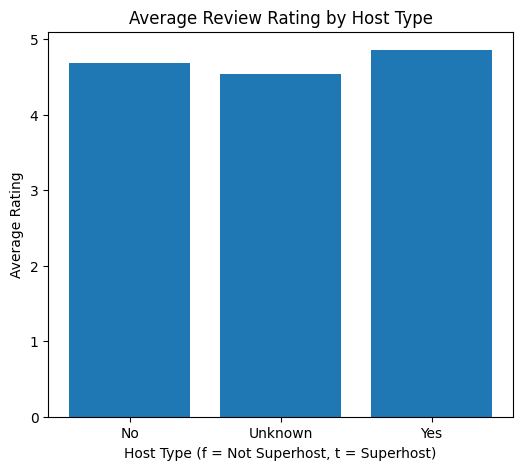

In [40]:
plt.figure(figsize=(6,5))

plt.bar(superhost_rating.index.astype(str),
        superhost_rating.values)

plt.title("Average Review Rating by Host Type")
plt.xlabel("Host Type (f = Not Superhost, t = Superhost)")
plt.ylabel("Average Rating")

plt.show()

### Business Insight

- Superhosts have the highest average review rating (4.86), indicating better overall guest satisfaction.
- Regular hosts also maintain high ratings, with an average score of 4.69.
- Hosts with unknown Superhost status have the lowest average rating, although they represent only a small proportion of the dataset.
- The results suggest an association between Superhost status and higher guest ratings.

## 📊 EDA 6: Top 10 Neighborhoods by Average Airbnb Price

### Business Question
Which neighborhoods have the highest average Airbnb listing prices in New York?

### Objective
Identify premium neighborhoods based on the average listing price.

In [41]:
avg_neighborhood_price = (
    airbnb
    .dropna(subset=['price'])
    .groupby('neighbourhood_cleansed')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_neighborhood_price

neighbourhood_cleansed
Civic Center          493.585714
NoHo                  451.156667
SoHo                  437.943910
Tribeca               436.989259
Financial District    420.875986
Theater District      413.513321
DUMBO                 410.130625
Greenwich Village     408.729310
Hollis Hills          396.255000
Midtown               395.500858
Name: price, dtype: float64

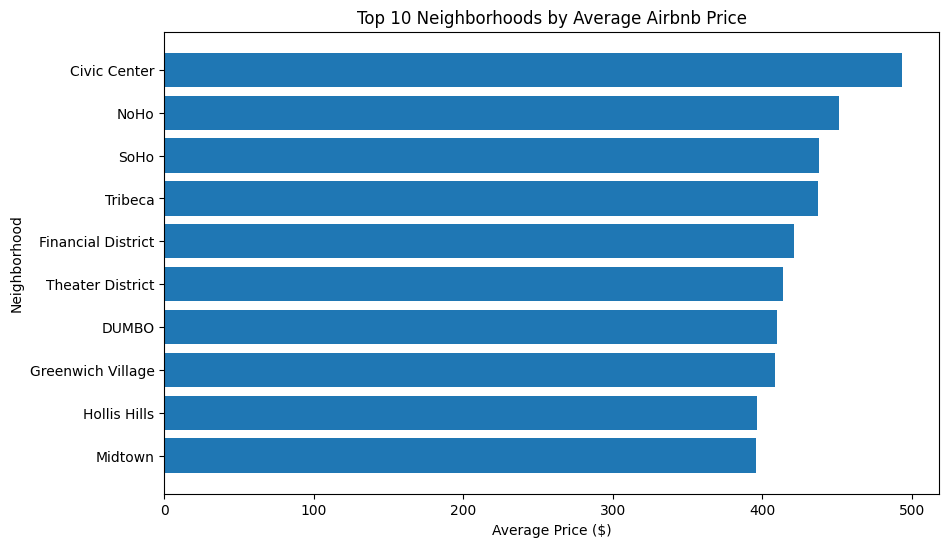

In [42]:
plt.figure(figsize=(10,6))

plt.barh(
    avg_neighborhood_price.index,
    avg_neighborhood_price.values
)

plt.title("Top 10 Neighborhoods by Average Airbnb Price")
plt.xlabel("Average Price ($)")
plt.ylabel("Neighborhood")

plt.gca().invert_yaxis()

plt.show()

### Business Insight

- Civic Center has the highest average Airbnb listing price, followed by NoHo and SoHo.
- Several neighborhoods have average listing prices exceeding $400, indicating a premium Airbnb market.
- Midtown appears in both the top neighborhoods by listing count and the top neighborhoods by average price, suggesting it combines high supply with relatively high pricing.
- The neighborhoods with the highest number of listings are not necessarily the most expensive, highlighting differences between market size and pricing.

## 📊 EDA 7: Average Estimated Revenue by Room Type

### Business Question
Which Airbnb room type generates the highest estimated annual revenue?

### Objective
Compare the estimated annual revenue across different room types to identify the most profitable accommodation category.

In [43]:
avg_revenue = (
    airbnb
    .dropna(subset=['estimated_revenue_l365d'])
    .groupby('room_type')['estimated_revenue_l365d']
    .mean()
    .sort_values(ascending=False)
)

avg_revenue

room_type
Entire home/apt    21736.298865
Shared room        18260.114583
Private room       14161.348377
Hotel room          6740.608333
Name: estimated_revenue_l365d, dtype: float64

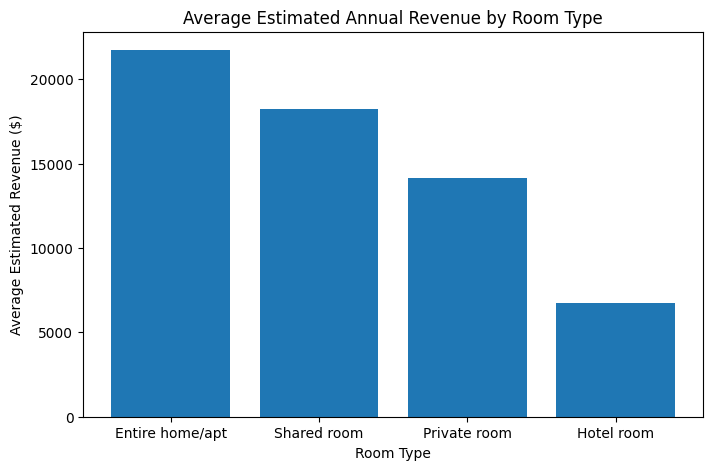

In [44]:
plt.figure(figsize=(8,5))

plt.bar(avg_revenue.index,
        avg_revenue.values)

plt.title("Average Estimated Annual Revenue by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Estimated Revenue ($)")

plt.show()

### Business Insight

- Entire homes generate the highest estimated annual revenue among all room types.
- Shared rooms rank second in estimated revenue despite having the lowest average nightly price, suggesting they may experience higher occupancy or reflecting the small number of shared room listings.
- Hotel rooms have the highest average nightly price but the lowest estimated annual revenue.
- The analysis shows that a higher nightly price does not always result in higher annual earnings.

## 📊 EDA 8: Relationship Between Price and Review Rating

### Business Question
Do higher-priced Airbnb listings receive better review ratings?

### Objective
Analyze the relationship between listing price and customer ratings.

In [47]:
scatter_df = airbnb.dropna(subset=['price', 'review_scores_rating'])

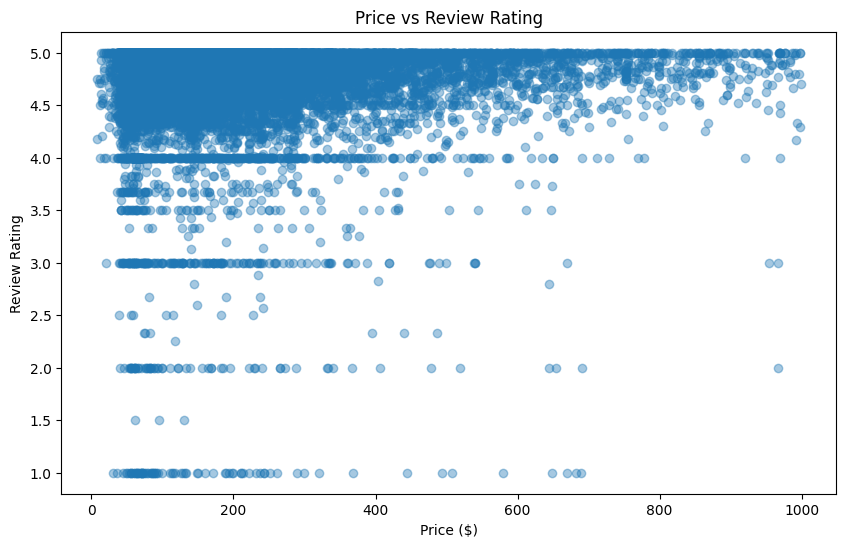

In [46]:
plt.figure(figsize=(10,6))

plt.scatter(
    scatter_df['price'],
    scatter_df['review_scores_rating'],
    alpha=0.4
)

plt.title("Price vs Review Rating")
plt.xlabel("Price ($)")
plt.ylabel("Review Rating")

plt.show()

### Business Insight

- Most Airbnb listings receive high review ratings, with the majority scoring between 4.5 and 5.0.
- Both low-priced and high-priced listings can achieve excellent customer ratings.
- Lower review ratings are observed across different price ranges rather than being concentrated among cheaper listings.
- The scatter plot suggests that there is no strong relationship between listing price and customer review ratings.

## 📊 EDA 9: Correlation Analysis

### Business Question
Which numerical features are most strongly related to one another?

### Objective
Identify positive and negative relationships between numerical variables using a correlation matrix and heatmap.

In [48]:
numerical_columns = [
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d'
]

correlation_matrix = airbnb[numerical_columns].corr()

correlation_matrix

,price,accommodates,bedrooms,beds,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,estimated_occupancy_l365d,estimated_revenue_l365d
price,1.000000,0.457958,0.255347,0.354569,0.137814,0.131292,0.120930,0.058041,0.006882,0.046408,0.137906,0.047265,0.407058
accommodates,0.457958,1.000000,0.669386,0.759721,0.072202,0.066761,0.070278,0.098602,-0.002762,-0.012412,0.043278,0.004781,0.204893
bedrooms,0.255347,0.669386,1.000000,0.744849,0.008133,0.012058,0.021424,0.061524,-0.009689,0.023518,-0.007433,0.025794,0.181576
beds,0.354569,0.759721,0.744849,1.000000,0.025440,0.016031,0.015531,0.034489,0.022889,0.015877,0.023710,0.027031,0.213423
availability_30,0.137814,0.072202,0.008133,0.025440,1.000000,0.945316,0.874068,0.527961,0.017466,-0.079194,0.134152,-0.060503,-0.076978
availability_60,0.131292,0.066761,0.012058,0.016031,0.945316,1.000000,0.964554,0.614376,0.029003,-0.080843,0.151447,-0.014877,-0.074756
availability_90,0.120930,0.070278,0.021424,0.015531,0.874068,0.964554,1.000000,0.708848,0.029376,-0.083255,0.152298,0.019201,-0.081760
availability_365,0.058041,0.098602,0.061524,0.034489,0.527961,0.614376,0.708848,1.000000,0.020724,-0.085814,0.119859,0.108441,-0.080932
number_of_reviews,0.006882,-0.002762,-0.009689,0.022889,0.017466,0.029003,0.029376,0.020724,1.000000,0.055281,0.750334,0.415079,0.243801
review_scores_rating,0.046408,-0.012412,0.023518,0.015877,-0.079194,-0.080843,-0.083255,-0.085814,0.055281,1.000000,0.037270,0.086221,0.078920


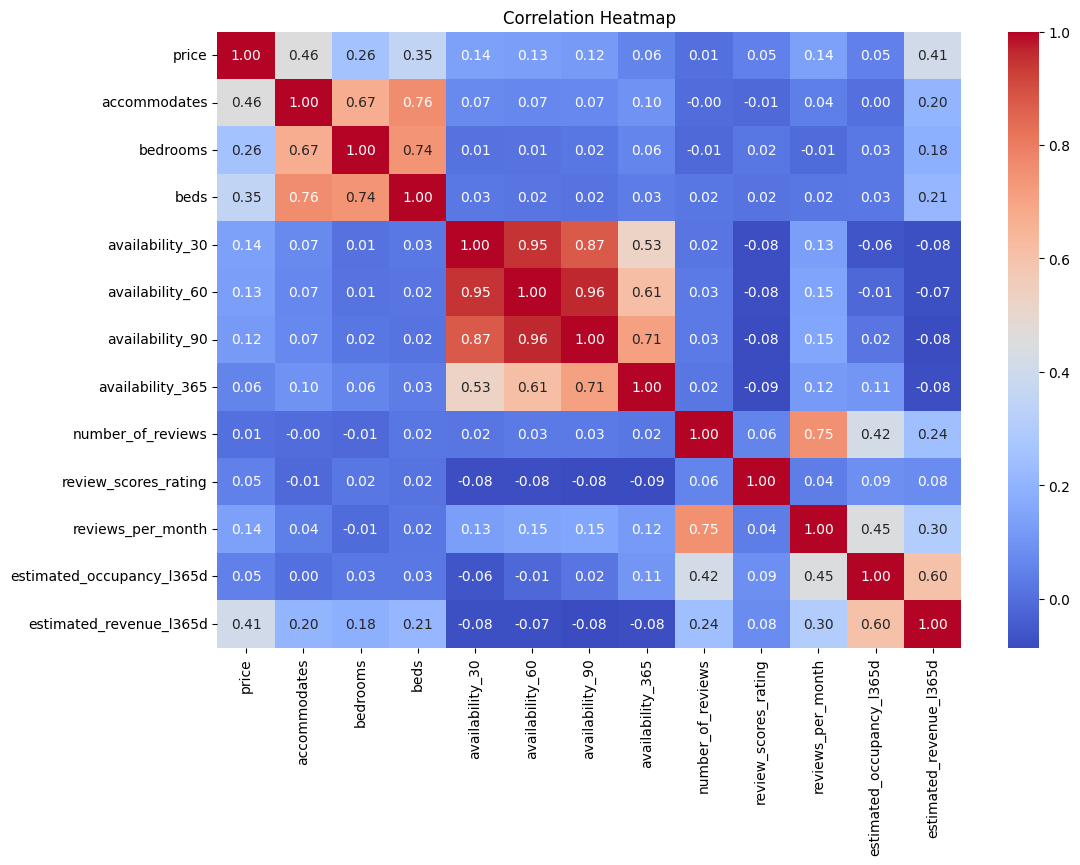

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insights

- Listings that accommodate more guests tend to have higher prices (correlation = 0.46).
- Estimated annual revenue is moderately correlated with occupancy (0.60), indicating that occupancy plays a key role in revenue generation.
- Number of reviews and reviews per month show a strong positive relationship (0.75), suggesting that active listings accumulate more reviews over time.
- Price has almost no correlation with review rating (0.05), indicating that expensive listings do not necessarily receive better customer ratings.
- Availability metrics are highly correlated because they measure listing availability over overlapping time periods.

### Business Insights

- Listings that accommodate more guests tend to have higher prices (correlation = 0.46).
- Estimated annual revenue is moderately correlated with occupancy (0.60), indicating that occupancy plays a key role in revenue generation.
- Number of reviews and reviews per month show a strong positive relationship (0.75), suggesting that active listings accumulate more reviews over time.
- Price has almost no correlation with review rating (0.05), indicating that expensive listings do not necessarily receive better customer ratings.
- Availability metrics are highly correlated because they measure listing availability over overlapping time periods.

## 📊 EDA 10: Availability Analysis

### Business Question
How available are Airbnb listings throughout the year?

### Objective
Analyze the distribution of annual listing availability.

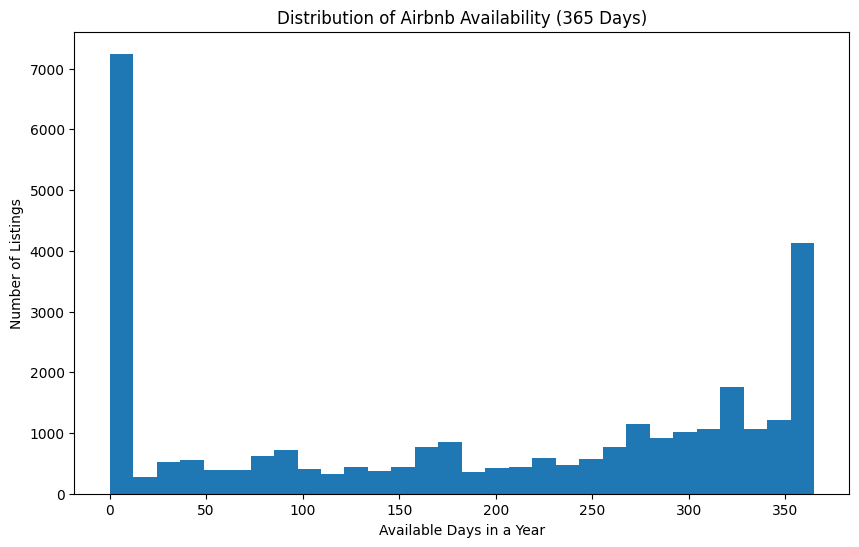

In [53]:
plt.figure(figsize=(10,6))

plt.hist(
    airbnb['availability_365'].dropna(),
    bins=30
)

plt.title("Distribution of Airbnb Availability (365 Days)")
plt.xlabel("Available Days in a Year")
plt.ylabel("Number of Listings")

plt.show()

### Business Insights

- A large number of Airbnb listings have very low annual availability, indicating they may be frequently booked or temporarily unavailable.
- Another significant group of listings remains available for most of the year, suggesting lower demand or hosts keeping their calendars open.
- The distribution shows two dominant availability patterns rather than a uniform spread across the year.
- Availability is an important factor when analyzing occupancy and estimated annual revenue.

## 📊 EDA 11: Top 10 Neighborhoods by Estimated Annual Revenue

### Business Question
Which neighborhoods generate the highest estimated annual revenue?

### Objective
Identify the top-performing neighborhoods based on average estimated annual Airbnb revenue.

In [54]:
top_revenue = (
    airbnb.groupby('neighbourhood_cleansed')['estimated_revenue_l365d']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue

neighbourhood_cleansed
DUMBO                 55536.588235
Financial District    44954.611621
Fort Hamilton         38779.790698
Civic Center          37565.000000
Cobble Hill           34410.714286
Columbia St           32620.500000
South Ozone Park      32550.519231
Middle Village        31792.230769
Tribeca               31514.486111
Gowanus               30941.962963
Name: estimated_revenue_l365d, dtype: float64

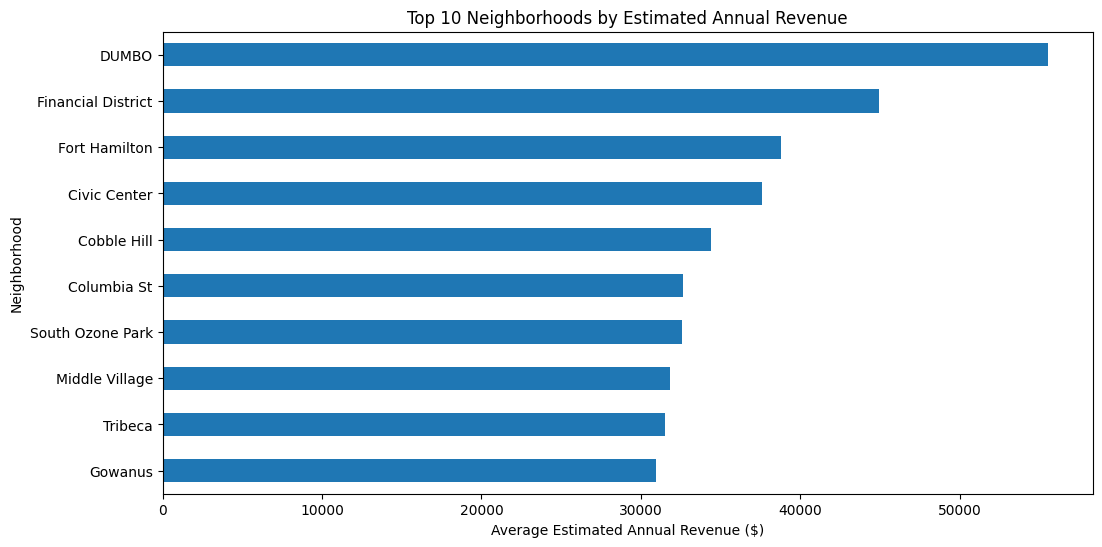

In [55]:
plt.figure(figsize=(12,6))

top_revenue.sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Neighborhoods by Estimated Annual Revenue")
plt.xlabel("Average Estimated Annual Revenue ($)")
plt.ylabel("Neighborhood")

plt.show()

### Business Insights

- DUMBO has the highest average estimated annual Airbnb revenue among all neighborhoods analyzed.
- Financial District and Civic Center also rank among the top-performing neighborhoods.
- High listing prices do not necessarily result in the highest annual revenue.
- Neighborhoods with strong booking demand and occupancy can outperform more expensive neighborhoods in terms of revenue.
- Revenue analysis provides a better measure of business performance than price alone.

## 📊 EDA 12: Average Price by Property Type

### Business Question
Which property types have the highest average Airbnb listing prices?

### Objective
Compare the average price across different property types.

In [56]:
top_property_price = (
    airbnb.groupby('property_type')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_property_price

property_type
Private room in resort        692.664118
Houseboat                     493.524000
Room in serviced apartment    453.962222
Entire serviced apartment     436.970351
Room in aparthotel            418.215370
Room in boutique hotel        406.312370
Room in bed and breakfast     399.230000
Room in hotel                 390.744070
Boat                          355.945000
Entire townhouse              327.189439
Name: price, dtype: float64

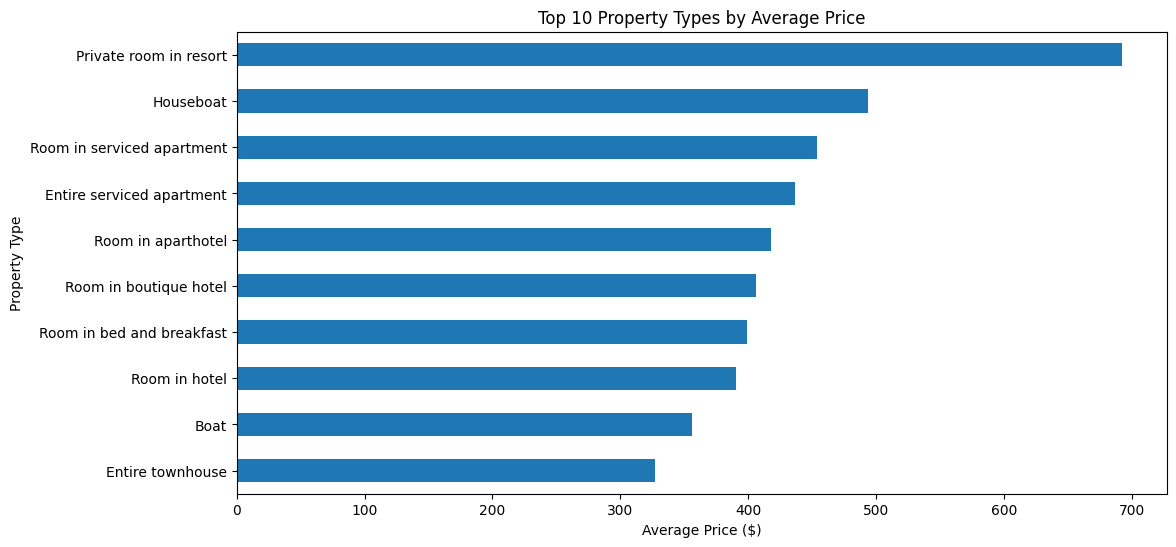

In [57]:
plt.figure(figsize=(12,6))

top_property_price.sort_values().plot(kind='barh')

plt.title("Top 10 Property Types by Average Price")
plt.xlabel("Average Price ($)")
plt.ylabel("Property Type")

plt.show()

In [58]:
property_count = airbnb['property_type'].value_counts()

property_count.head(20)

property_type
Entire rental unit                   13107
Private room in rental unit           6858
Private room in home                  2482
Room in hotel                         1681
Entire home                           1222
Private room in townhouse             1026
Entire condo                           966
Entire townhouse                       424
Entire loft                            385
Private room in condo                  382
Entire guest suite                     273
Room in boutique hotel                 220
Entire serviced apartment              199
Shared room in rental unit             164
Private room in loft                   136
Private room in guest suite            132
Room in aparthotel                      62
Entire place                            54
Private room in bed and breakfast       52
Private room in resort                  45
Name: count, dtype: int64

### Business Insights

- Resort rooms have the highest average listing price (~$693), indicating they target premium travelers.
- Houseboats and serviced apartments also command premium prices due to their unique accommodation experience.
- Hospitality-oriented property types such as boutique hotels and aparthotels consistently have higher average prices.
- Larger residential properties like entire townhouses remain expensive because of increased space and capacity.

### Business Insights

- Resort rooms have the highest average listing price (~$693), indicating they target premium travelers.
- Houseboats and serviced apartments also command premium prices due to their unique accommodation experience.
- Hospitality-oriented property types such as boutique hotels and aparthotels consistently have higher average prices.
- Larger residential properties like entire townhouses remain expensive because of increased space and capacity.

In [59]:
top_property_revenue = (
    airbnb.groupby("property_type")["estimated_revenue_l365d"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_property_revenue

property_type
Shared room in townhouse             111558.600000
Room in aparthotel                    79263.152542
Private room in ranch                 57714.000000
Private room in cottage               49567.000000
Entire guest suite                    47589.602564
Shared room in serviced apartment     44505.000000
Entire bungalow                       42802.571429
Shared room in guesthouse             42671.000000
Entire townhouse                      39014.897590
Private room in guesthouse            38205.411765
Name: estimated_revenue_l365d, dtype: float64

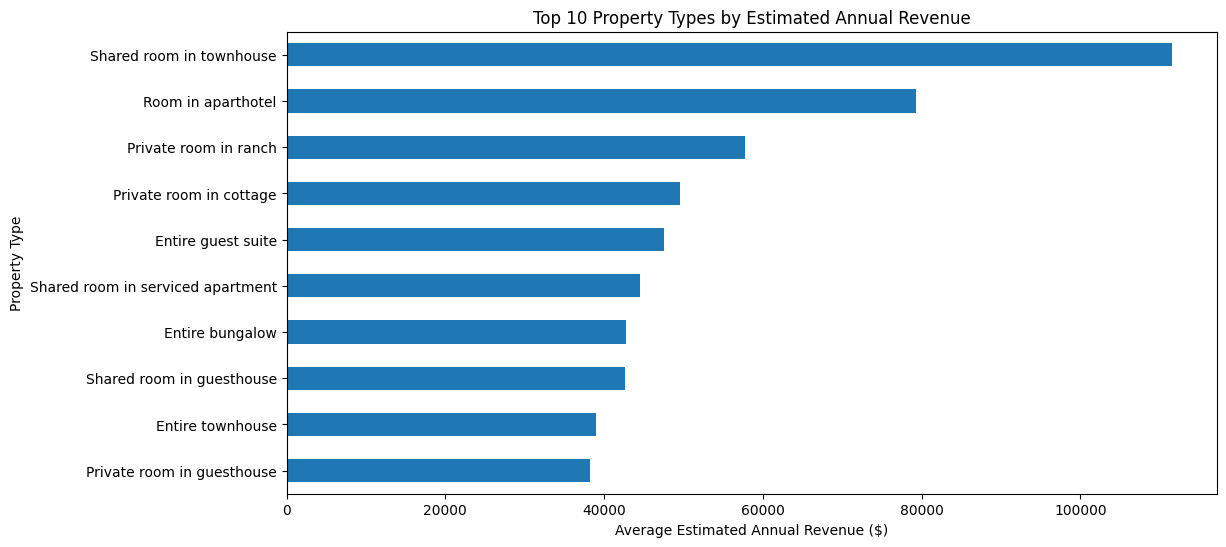

In [60]:
plt.figure(figsize=(12,6))

top_property_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Property Types by Estimated Annual Revenue")
plt.xlabel("Average Estimated Annual Revenue ($)")
plt.ylabel("Property Type")

plt.show()

In [61]:
airbnb["property_type"].value_counts().head(20)

property_type
Entire rental unit                   13107
Private room in rental unit           6858
Private room in home                  2482
Room in hotel                         1681
Entire home                           1222
Private room in townhouse             1026
Entire condo                           966
Entire townhouse                       424
Entire loft                            385
Private room in condo                  382
Entire guest suite                     273
Room in boutique hotel                 220
Entire serviced apartment              199
Shared room in rental unit             164
Private room in loft                   136
Private room in guest suite            132
Room in aparthotel                      62
Entire place                            54
Private room in bed and breakfast       52
Private room in resort                  45
Name: count, dtype: int64

### Business Insights

- Shared rooms in townhouses report the highest average annual revenue, though this may be influenced by a small number of listings and when checked they aren't listed even in top 20.
- Aparthotels consistently generate strong annual revenue due to higher occupancy and professional management.
- Entire townhouses appear in both the highest-price and highest-revenue analyses, indicating strong earning potential.
- Property types with the highest nightly prices do not necessarily generate the highest yearly revenue.
- Annual revenue is influenced by both pricing and occupancy, making it a more comprehensive performance metric.

## 📊 EDA 14: Average Number of Reviews by Room Type

### Business Question
Which room types receive the highest average number of guest reviews?

### Objective
Compare guest engagement across different room types.

In [62]:
avg_reviews = (
    airbnb.groupby("room_type")["number_of_reviews"]
    .mean()
    .sort_values(ascending=False)
)

avg_reviews

room_type
Private room       40.396523
Shared room        32.582569
Entire home/apt    27.047358
Hotel room         10.146154
Name: number_of_reviews, dtype: float64

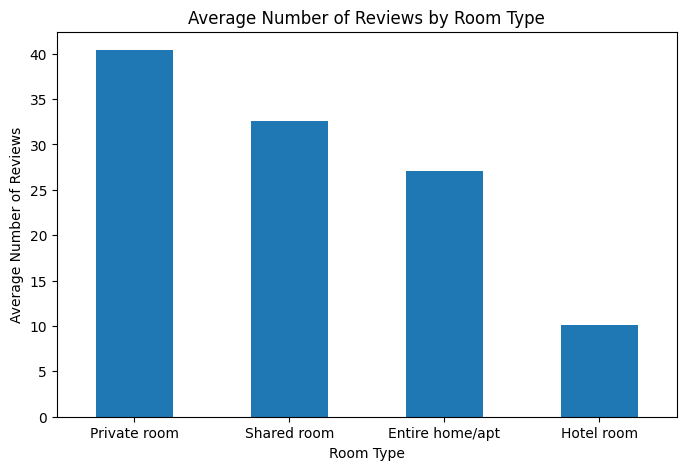

In [63]:
plt.figure(figsize=(8,5))

avg_reviews.plot(kind="bar")

plt.title("Average Number of Reviews by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Number of Reviews")

plt.xticks(rotation=0)

plt.show()

### Business Insights

- Private rooms receive the highest average number of guest reviews, indicating strong guest engagement and frequent bookings.
- Shared rooms also show relatively high review counts despite having fewer listings.
- Entire homes generate higher revenue but receive fewer reviews, suggesting fewer bookings at higher prices or longer stays.
- Hotel rooms have the lowest average number of reviews, likely due to lower representation on Airbnb and alternative booking channels.

## 📊 EDA 15: Occupancy vs Estimated Annual Revenue

### Business Question
Does higher occupancy result in higher estimated annual revenue?

### Objective
Analyze the relationship between occupancy and annual revenue to understand whether frequently booked listings earn more over time.

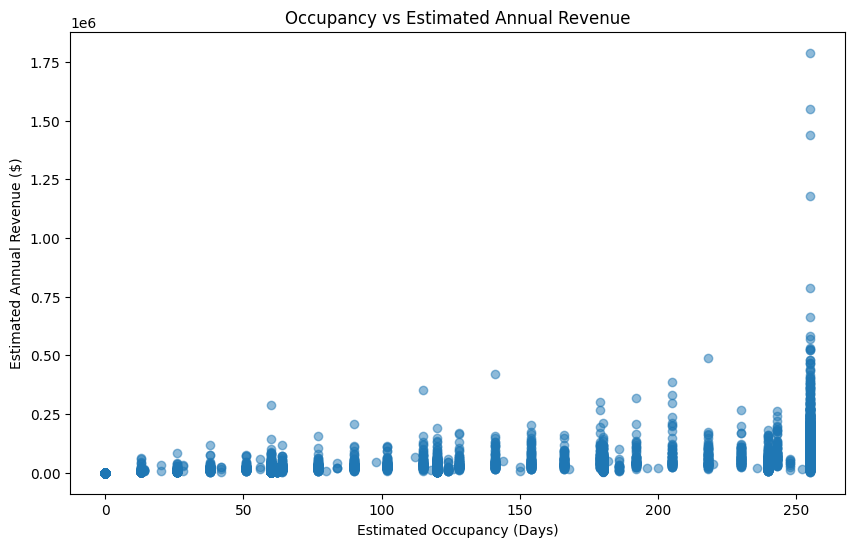

In [64]:
plt.figure(figsize=(10,6))

plt.scatter(
    airbnb["estimated_occupancy_l365d"],
    airbnb["estimated_revenue_l365d"],
    alpha=0.5
)

plt.title("Occupancy vs Estimated Annual Revenue")
plt.xlabel("Estimated Occupancy (Days)")
plt.ylabel("Estimated Annual Revenue ($)")

plt.show()

In [65]:
airbnb[
    ["estimated_occupancy_l365d",
     "estimated_revenue_l365d"]
].corr()

,estimated_occupancy_l365d,estimated_revenue_l365d
estimated_occupancy_l365d,1.00000,0.60457
estimated_revenue_l365d,0.60457,1.00000


### Business Insights

- Estimated occupancy and annual revenue have a moderate positive correlation (0.60).
- Listings with higher occupancy generally earn higher annual revenue.
- Occupancy alone does not determine revenue; pricing and property characteristics also have a substantial impact.
- Several high-revenue outliers indicate the presence of premium or luxury listings.

## 📊 EDA 16: Average Price by Number of Bedrooms

### Business Question
How does the average nightly price change with the number of bedrooms?

### Objective
Analyze whether larger properties command higher prices.

In [70]:
price_bedrooms = (
    airbnb.groupby("bedrooms")["price"]
    .mean()
    .dropna()
    .sort_index()
)

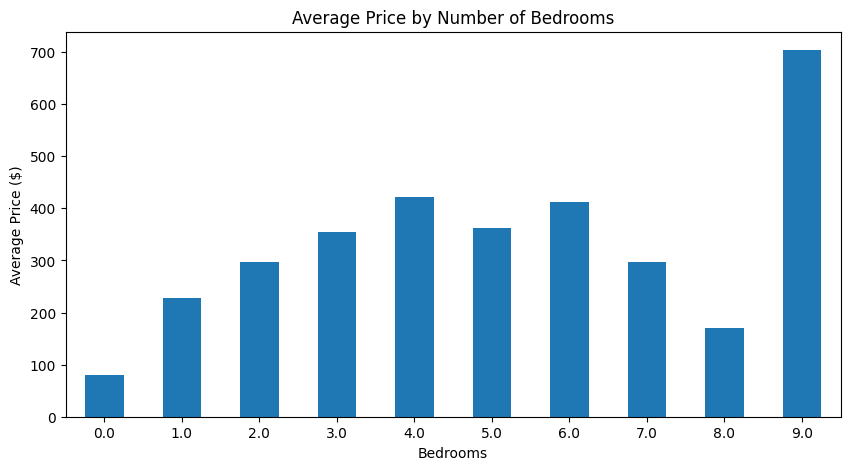

In [69]:
plt.figure(figsize=(10,5))

price_bedrooms.plot(kind="bar")

plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")

plt.xticks(rotation=0)

plt.show()

### Business Insights

- Average nightly price generally increases with the number of bedrooms.
- Larger properties command premium prices because they can accommodate more guests.
- Four-bedroom and larger properties show substantially higher prices than one- or two-bedroom listings.
- Although nine-bedroom properties have the highest average price, the result is based on very few listings and should be interpreted cautiously.

## 📊 EDA 17: Average Estimated Annual Revenue by Number of Bedrooms

### Business Question
Do larger properties generate higher estimated annual revenue?

### Objective
Compare the average estimated annual revenue across properties with different numbers of bedrooms.

In [71]:
revenue_bedrooms = (
    airbnb.groupby("bedrooms")["estimated_revenue_l365d"]
    .mean()
    .dropna()
    .sort_index()
)

revenue_bedrooms

bedrooms
0.0       4210.500000
1.0      14077.104104
2.0      24469.311031
3.0      34245.920996
4.0      47482.240310
5.0      64211.230159
6.0      47069.318182
7.0       5544.363636
8.0     332419.857143
9.0      12989.500000
10.0         0.000000
12.0         0.000000
14.0         0.000000
15.0         0.000000
19.0         0.000000
Name: estimated_revenue_l365d, dtype: float64

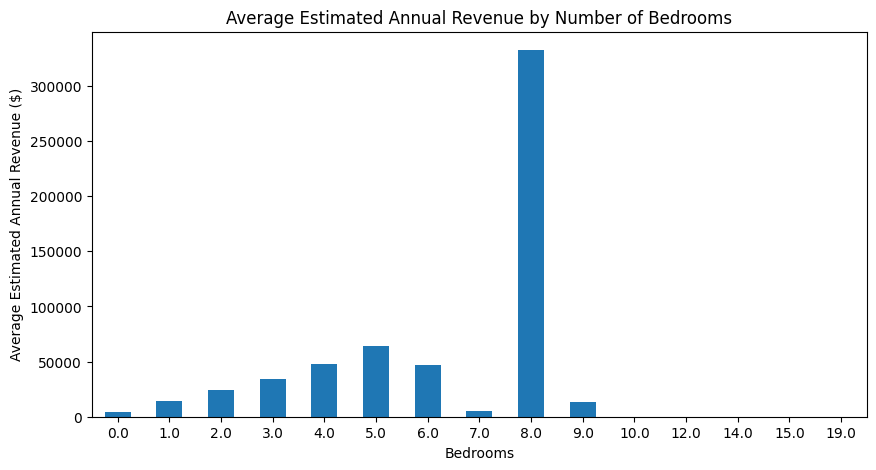

In [72]:
plt.figure(figsize=(10,5))

revenue_bedrooms.plot(kind="bar")

plt.title("Average Estimated Annual Revenue by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Estimated Annual Revenue ($)")

plt.xticks(rotation=0)

plt.show()

### Business Insights

- Estimated annual revenue generally increases as the number of bedrooms increases.
- Properties with four and five bedrooms generate substantially higher annual revenue than smaller listings.
- Eight-bedroom properties show exceptionally high revenue, but this result is based on a very small number of listings and should be interpreted cautiously.
- Revenue is influenced not only by property size but also by occupancy, pricing, and demand.

In [73]:
airbnb.isnull().sum()

id                               0
neighbourhood_cleansed           0
latitude                         0
longitude                        0
property_type                    0
room_type                        0
accommodates                     0
bedrooms                     10973
beds                          9420
price                         9368
availability_30                  0
availability_60                  0
availability_90                  0
availability_365                 0
number_of_reviews                0
review_scores_rating          8559
reviews_per_month             8559
estimated_occupancy_l365d        0
estimated_revenue_l365d       8744
host_is_superhost                0
dtype: int64

In [74]:
airbnb["bedrooms"].describe()

count    19286.000000
mean         1.573473
std          0.918719
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         19.000000
Name: bedrooms, dtype: float64

In [75]:
airbnb["bedrooms"].median()

1.0

In [76]:
airbnb["bedrooms"] = airbnb["bedrooms"].fillna(
    airbnb["bedrooms"].median()
)

In [77]:
airbnb["bedrooms"].isnull().sum()

np.int64(0)

In [78]:
airbnb["beds"].describe()

count    20839.000000
mean         1.716685
std          1.252760
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         40.000000
Name: beds, dtype: float64

In [79]:
airbnb["beds"].median()

1.0

In [80]:
airbnb["beds"] = airbnb["beds"].fillna(
    airbnb["beds"].median()
)

In [81]:
airbnb["beds"].isnull().sum()

np.int64(0)

In [82]:
airbnb[airbnb["price"].isnull()]["room_type"].value_counts()

room_type
Entire home/apt    5676
Private room       3557
Hotel room          105
Shared room          30
Name: count, dtype: int64

In [83]:
airbnb[airbnb["price"].isnull()]["property_type"].value_counts().head(10)

property_type
Entire rental unit             4712
Private room in rental unit    2163
Room in hotel                   477
Private room in townhouse       399
Private room in home            359
Entire condo                    345
Entire home                     237
Entire loft                     149
Entire townhouse                121
Private room in condo            90
Name: count, dtype: int64

In [84]:
airbnb.groupby("room_type")["price"].median()

room_type
Entire home/apt    216.915
Hotel room         399.000
Private room       101.000
Shared room         53.095
Name: price, dtype: float64

In [85]:
airbnb["price"] = airbnb.groupby("room_type")["price"].transform(
    lambda x: x.fillna(x.median())
)

In [86]:
airbnb["price"].isnull().sum()

np.int64(0)

In [87]:
airbnb["review_scores_rating"].describe()

count    21700.000000
mean         4.732956
std          0.447274
min          0.000000
25%          4.670000
50%          4.860000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

In [88]:
airbnb["review_scores_rating"].median()

4.86

In [89]:
airbnb["reviews_per_month"] = airbnb["reviews_per_month"].fillna(0)

In [90]:
airbnb["reviews_per_month"].isnull().sum()

np.int64(0)

In [91]:
airbnb["estimated_revenue_l365d"].describe()

count    2.151500e+04
mean     1.809429e+04
std      4.397775e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.954350e+04
max      1.788741e+06
Name: estimated_revenue_l365d, dtype: float64

In [92]:
airbnb["estimated_revenue_l365d"].median()

0.0

In [93]:
airbnb.loc[
    airbnb["estimated_revenue_l365d"].isnull(),
    ["estimated_occupancy_l365d", "number_of_reviews", "availability_365"]
].describe()

,estimated_occupancy_l365d,number_of_reviews,availability_365
count,8744.000000,8744.000000,8744.000000
mean,9.984561,15.747713,37.923262
std,40.051447,36.930378,96.356576
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000
75%,0.000000,13.000000,0.000000
max,255.000000,669.000000,365.000000


In [94]:
airbnb["estimated_revenue_l365d"] = airbnb["estimated_revenue_l365d"].fillna(0)

In [95]:
airbnb["estimated_revenue_l365d"].isnull().sum()

np.int64(0)

In [96]:
airbnb.isnull().sum()

id                              0
neighbourhood_cleansed          0
latitude                        0
longitude                       0
property_type                   0
room_type                       0
accommodates                    0
bedrooms                        0
beds                            0
price                           0
availability_30                 0
availability_60                 0
availability_90                 0
availability_365                0
number_of_reviews               0
review_scores_rating         8559
reviews_per_month               0
estimated_occupancy_l365d       0
estimated_revenue_l365d         0
host_is_superhost               0
dtype: int64

In [97]:
airbnb.to_csv("../datasets/processed/new_york_cleaned.csv", index=False)

In [98]:
test = pd.read_csv("../datasets/processed/new_york_cleaned.csv")
test.head()

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,price,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,reviews_per_month,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost
0,2539,Kensington,40.645937,-73.972164,Private room in condo,Private room,2,1.0,2.0,113.97,4,34,64,339,10,4.80,0.08,60,6838.0,No
1,6848,Williamsburg,40.709350,-73.953420,Entire rental unit,Entire home/apt,3,2.0,1.0,117.27,1,1,15,191,198,4.60,0.95,180,21109.0,Yes
2,6872,East Harlem,40.801070,-73.942550,Private room in condo,Private room,1,1.0,1.0,80.06,0,0,11,286,2,5.00,0.04,60,4804.0,No
3,6990,East Harlem,40.787780,-73.947590,Private room in rental unit,Private room,1,1.0,1.0,77.17,0,28,28,218,251,4.88,1.24,120,9260.0,Yes
4,7097,Fort Greene,40.691940,-73.973890,Private room in guest suite,Private room,2,1.0,2.0,202.47,0,0,0,106,423,4.89,2.12,255,51630.0,Yes
